### Matplotlib

Matplotlib is a multiplatform data visualization library built on NumPy arrays and designed to work with the broader SciPy stack. 

**Getting Started with `matplotlib`**

1. To install: `pip install matplotlib` 
2. To embed matplotlib in the notebook run the `%matplotlib inline`

In [1]:
import sys
!{sys.executable} -m pip install matplotlib 

%matplotlib inline


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

#### Basic Concepts

- [`figure`](https://matplotlib.org/api/figure_api.html?highlight=figure#module-matplotlib.figure): A figure may contain 1+ axes (plots).

- [`axes`](https://matplotlib.org/api/axes_api.html?highlight=axes#module-matplotlib.axes): The plot(s), a figure can include many axes. Axes have a title, an x-label, and a y-label.

- [`axis`](https://matplotlib.org/api/axis_api.html?highlight=axis#module-matplotlib.axis): Number line like objects that generate the graph limits.

- [`artist`](https://matplotlib.org/api/artist_api.html?highlight=artist#module-matplotlib.artist): Everything within a figure like `Text`, `Line2D`, and `collection` objects.  

### Creating a plot

1. Instantiate two `numpy` arrays
2. Instantiate a [`plot`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html?highlight=plot#matplotlib.pyplot.plot) with those arrays
3. `show` the plot

In [3]:
import numpy as np

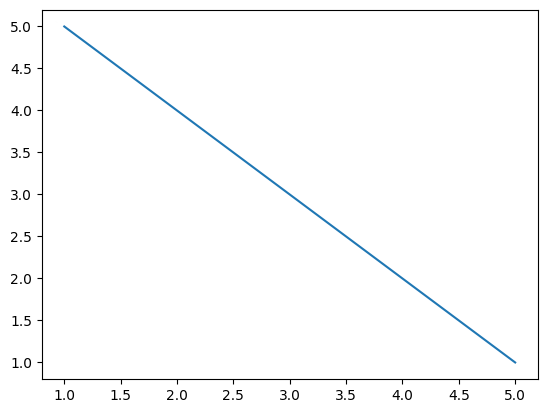

In [4]:
arr_one = np.array([5,4,3,2,1])
arr_two = np.array([1,2,3,4,5])
plt.plot(arr_one, arr_two)
plt.show()

`plt.plot` when called as `plt.plot(x,y)` creates an array with the first array as the `x` coordinates and the second array as the `y` coordinates

In [5]:
help(plt.plot)

Help on function plot in module matplotlib.pyplot:

plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'
    Plot y versus x as lines and/or markers.
    
    Call signatures::
    
        plot([x], y, [fmt], *, data=None, **kwargs)
        plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)
    
    The coordinates of the points or line nodes are given by *x*, *y*.
    
    The optional parameter *fmt* is a convenient way for defining basic
    formatting like color, marker and linestyle. It's a shortcut string
    notation described in the *Notes* section below.
    
    >>> plot(x, y)        # plot x and y using default line style and color
    >>> plot(x, y, 'bo')  # plot x and y using blue circle markers
    >>> plot(y)           # plot y using x as index array 0..N-1
    >>> plot(y, 'r+')     # ditto, but with red plusses
    
    You can use `.Line2D` properties as keyword arguments for more
    control on 

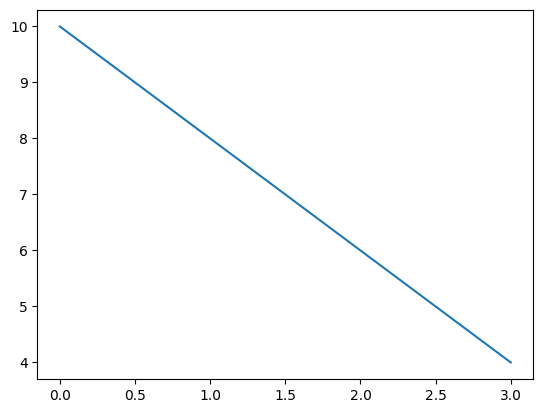

In [6]:
arr_one = np.array([10, 8, 6, 4])
plt.plot(arr_one)
plt.show()  # Uses the index of the input array as the x coordinates

### Set the title, x label, and y label

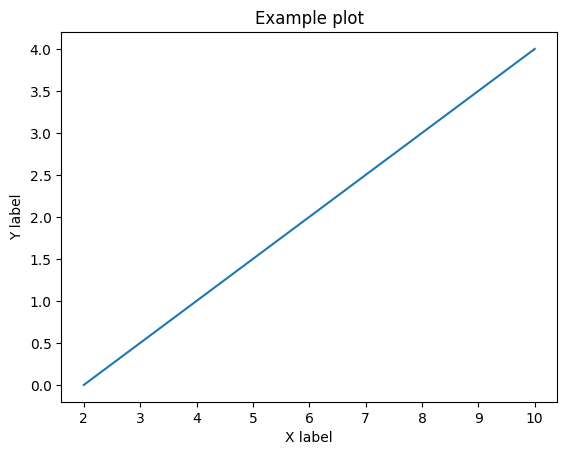

In [7]:
arr_one = np.array([2,4,6,8,10])
arr_two = np.arange(5)
plt.title("Example plot")
plt.xlabel("X label")
plt.ylabel("Y label")
plt.plot(arr_one, arr_two)
plt.show()

### Plotting multiple lines

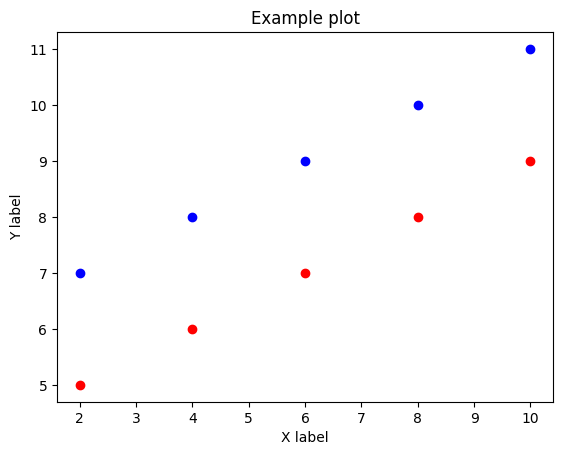

In [8]:
# Line 1
arr_one = np.array([2,4,6,8,10])
arr_two = np.arange(5)
arr_two += 5
plt.plot(arr_one, arr_two, 'ro')   # Plot with red circles

# Line 2
arr_three = np.array([2,4,6,8,10])
arr_four = np.arange(5)
arr_four += 7
plt.plot(arr_three, arr_four, 'bo') # Plot with blue circles

plt.title("Example plot")
plt.xlabel("X label")
plt.ylabel("Y label")

plt.show()

### Plotting labelled data  

First let's review NumPy structured arrays:

In [9]:
names = ['James T Kirk', 'Jean-Luc Picard', 'Benjamin Sisko', 'Kathryn Janeway', 'Jonathan Archer', 'Gabriel Lorca', 'Saru']
ranking = [7, 1, 2, 3, 6, 5, 4]

# Create structure aray with all zeros
star_trek_captains = np.zeros(7, dtype={'names': ('name', 'ranking'), 'formats': ('U15', 'i4')})

# Populate with data!
star_trek_captains['name'] = names
star_trek_captains['ranking'] = ranking

# Sort based on my very biased ranking!
star_trek_captains = np.sort(star_trek_captains, order='ranking')

print(star_trek_captains)
print(star_trek_captains.shape)    # row X col
print(star_trek_captains.ndim)     # num of dimensions

[('Jean-Luc Picard', 1) ('Benjamin Sisko', 2) ('Kathryn Janeway', 3)
 ('Saru', 4) ('Gabriel Lorca', 5) ('Jonathan Archer', 6)
 ('James T Kirk', 7)]
(7,)
1


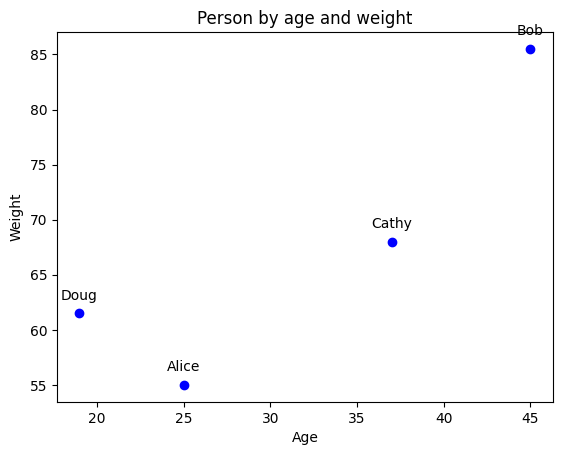

In [10]:
# Line 1
name = ['Alice', 'Bob', 'Cathy', 'Doug']
age = [25, 45, 37, 19]
weight = [55.0, 85.5, 68.0, 61.5]
data = np.zeros(4, dtype={'names':('name', 'age', 'weight'),
                          'formats':('U10', 'i4', 'f8')})

data['name'] = name
data['age'] = age
data['weight'] = weight

plt.plot(data['age'],data['weight'],'bo')

for val in data:

    label = f'{val["name"]}'

    plt.annotate(label, # this is the text
                 (val['age'],val['weight']), # this is the point to label
                 textcoords="offset points", # how to position the text
                 xytext=(0,10), # distance from text to points (x,y)
                 ha='center') # horizontal alignment can be left, right or center


plt.title("Person by age and weight")
plt.xlabel("Age")
plt.ylabel("Weight")

plt.show()

In [11]:
help(plt.annotate)

Help on function annotate in module matplotlib.pyplot:

annotate(text: 'str', xy: 'tuple[float, float]', xytext: 'tuple[float, float] | None' = None, xycoords: 'CoordsType' = 'data', textcoords: 'CoordsType | None' = None, arrowprops: 'dict[str, Any] | None' = None, annotation_clip: 'bool | None' = None, **kwargs) -> 'Annotation'
    Annotate the point *xy* with text *text*.
    
    In the simplest form, the text is placed at *xy*.
    
    Optionally, the text can be displayed in another position *xytext*.
    An arrow pointing from the text to the annotated point *xy* can then
    be added by defining *arrowprops*.
    
    Parameters
    ----------
    text : str
        The text of the annotation.
    
    xy : (float, float)
        The point *(x, y)* to annotate. The coordinate system is determined
        by *xycoords*.
    
    xytext : (float, float), default: *xy*
        The position *(x, y)* to place the text at. The coordinate system
        is determined by *textcoords*.

### Plotting Multiple Plots in One Figure

Using `plt.subplot` we can add more than one plot to a figure. `plt.subplot` accepts three arguments:

- `nrows`
- `ncols`
- `index`

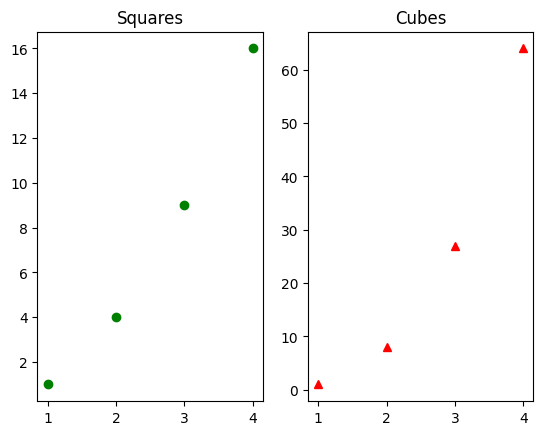

In [12]:
x = np.arange(1,5)
y = x**3

plt.subplot(1,2,1)
plt.plot([1,2,3,4],[1,4,9,16],'go')
plt.title("Squares")

plt.subplot(1,2,2)
plt.plot(x,y,'r^')
plt.title("Cubes")

plt.show()

Making your sub-plots like this can become repetative, therefore we can make many subplots at once with `plt.subplots`, this accepts:

- `nrows`
- `ncols` 

Upon using `plt.subplots` you get two objects: `figure`, and `axes`

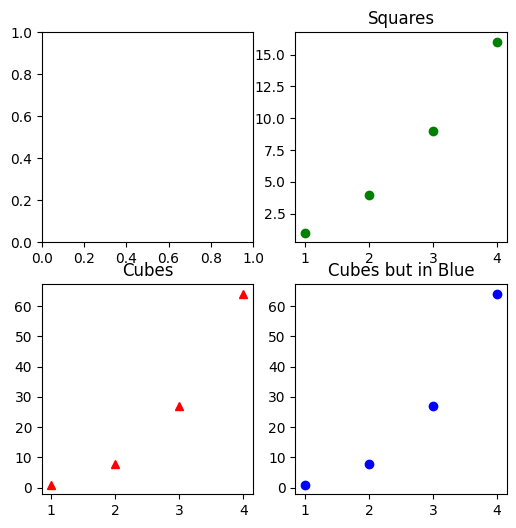

In [13]:
x = np.arange(1,5)
y = x**3
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(6,6))
ax[0,1].plot([1,2,3,4],[1,4,9,16],'go')
ax[1,0].plot(x,y,'r^')
ax[0,1].set_title("Squares")
ax[1,0].set_title("Cubes")
ax[1, 1].plot(x,y,'bo')
ax[1,1].set_title("Cubes but in Blue")

plt.show()

### Making other types of graphs

You can also make:

- bar graphs
- pie charts
- histograms
- scatter plots and 3D plotting

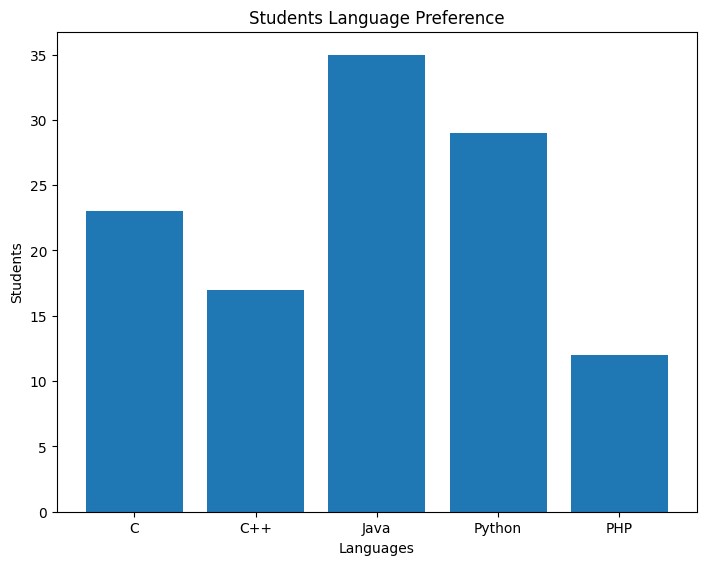

In [14]:
figure = plt.figure()
ax = figure.add_axes([0,0,1,1])
languages = ['C', 'C++', 'Java', 'Python', 'PHP']
students = [23, 17, 35, 29, 12]
ax.bar(languages,students)
plt.title('Students Language Preference')
plt.xlabel('Languages')
plt.ylabel('Students')
plt.show()

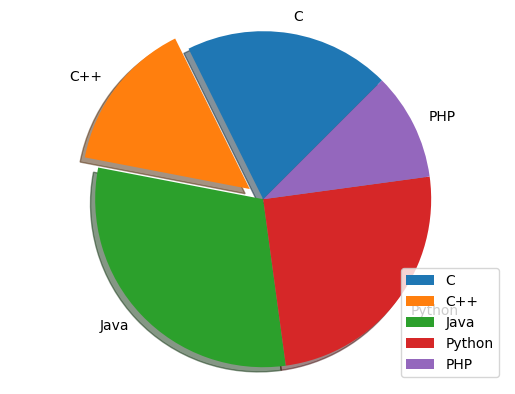

In [15]:
languages = ['C', 'C++', 'Java', 'Python', 'PHP']
students = [23, 17, 35, 29, 12]
explode = [0,0.1,0,0,0]
plt.pie(students,explode=explode,labels=languages,shadow=True,startangle=45)
plt.axis('equal')
plt.legend(languages)
plt.show()

Text(0.5, 0, 'Data')

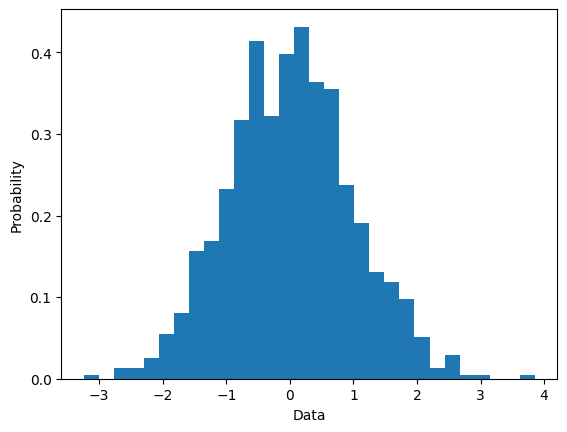

In [16]:
np.random.seed(42)
x = np.random.normal(size=1000)
plt.hist(x, density=True, bins=30)  # `density=False` would make counts
plt.ylabel('Probability')
plt.xlabel('Data')

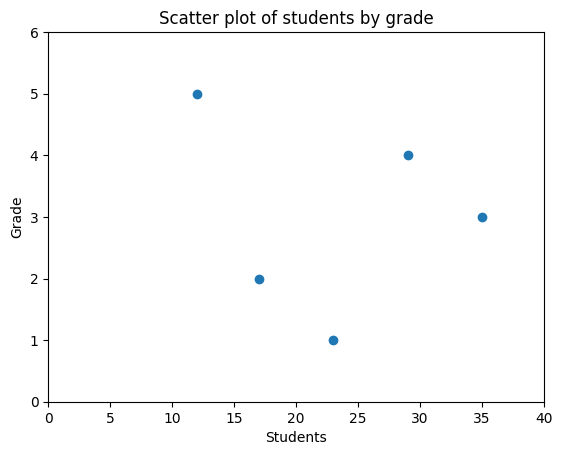

In [17]:
grade = [1, 2, 3, 4, 5]
students = [23, 17, 35, 29, 12]
plt.xlim(0,40)  # Set limits of x and y
plt.ylim(0,6)
plt.scatter(students,grade)
plt.title('Scatter plot of students by grade')
plt.xlabel('Students')
plt.ylabel('Grade')
plt.show()